# Image Classification ML Assignment 

The goal of this assignment is to learn fundamentals of machine learning and image analysis. You will analyze images from Happy Whale, an organization that tracks whales globally, and modify a classifier for these images. 

Part 1: Walk through (Due Feb 27)
- In class, we will walk through the provided code
- This script has several functions that are written for you. For part 1, please do NOT modify any code unless it specifies to change it.
- Answer the questions as you go through the code

Part 2: Make modifications (Due Feb 27)
- Change model parameters or other model aspects at least 3 times 
- Describe what happened when you made these changes

Part 3: Create a team, get inspired and try a new approach to your model (Due March 6)
- Have a group meeting and record your meeting with audio or video (you can record with zoom!)
    - Start by discussing part 2 of the assignment:
        - What approaches you each took to change the ML model in part 2
        - What are similarities and differences between your approaches 
        - What types of changes improved model performance
        - What types of changes made model performance worse
        - Based on the whole group's work, what would y'all want to do next in terms of model optimization?
    - Next, look at code and approaches from the [Happy Whales competition leaderboard](https://www.kaggle.com/competitions/happy-whale-and-dolphin/leaderboard).
        - Is there any strategy that someone used that you could implement? 
            - Ex: learning rate value, # epochs, transformation strategy, or more complex changes to the models
        - Are there strategies that you are interested in learning about?
    - Lastly, make a plan for 1 more round of model optimization
        - Assign each member something to attempt for training the model. Use your cumulative experience to decide the most important things to test. 
        - Group members can make as small as changing the value for a parameter or as big as changing the model.
- Have each member complete their test
- Share results with each other
- Write a 1-3 paragraph summary on your group's attempts and recommendations moving forward
- For Part 3: Turn in the audio/video recording of the group meeting, each member's code (uploaded to their original git repo), and the team's 1-3 paragraph summary over canvas.

### Your choices on data
You can chose between 3 datasets for this assignment. This jupyter notebook is set up using the Species dataset. If you change the dataset, you will need to change the number of classes parameter for the model.
- Species = you will classify images by species (gray, killer, beluga, humpback, false killer, and common dolphin)
  - File path: /projects/bgmp/shared/Bi625/ML_Assignment/Datasets/Whale_species/species
- Species_all = you will classify images by species (minke, gray, killer, beluga, humpback, false killer, and bottlenose and common dolphin). There are a high number of images for bottlenose dolphins and minke whales which leads to this dataset being quite large. Due to the size of the dataset, it has a longer training time than the "Species" dataset.
  - File path: /projects/bgmp/shared/Bi625/ML_Assignment/Datasets/Whale_species/species_all
  - Num classes: 8
- Individuals = you will classify images by individuals. This is a much more challenging classification task because you have different individuals from different species. However, this was the original goal of the Happy Whale competition, so try challenging yourself to this important task!
  - File path: /projects/bgmp/shared/Bi625/ML_Assignment/Datasets/Whale_species/individuals
  - Num classes: 110

You are NOT graded by the success of your model, so you are free to train the model on whichever dataset is more interesting to you. However, **everyone on your team for part 3 should be using the same dataset**.

# Part 1

In [1]:
## Importing packages - Please DO NOT alter this box ##
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from torch.nn import functional as F
import torch.optim as optim
from torch.utils.data.sampler import WeightedRandomSampler
torch.manual_seed(0)

from captum.attr import IntegratedGradients
from captum.attr import DeepLift
from captum.attr import NoiseTunnel
from captum.attr import visualization as viz

import torchvision
from torchvision import datasets, transforms
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter()

import os
import imageio
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from tqdm import tqdm
from scipy.ndimage import binary_erosion
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns

import wandb #comment this out if you are not using weights and biases
import random #comment this out if you are not using weights and biases

# Set device to cuda if it's available otherwise default to "cpu"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### Loading in the dataset

By default, this will load in the species dataset, this is the smallest dataset (i.e., it will be relatively fast to train) and has a simple goal (i.e., you will be able to create an accurate model). If you want a challenge, I highly encourage you to try the Species_all (a dataset with 2 additional species) or the individual dataset (a dataset where whales are characterized by individual rather than species).

In [2]:
images = "/projects/bgmp/shared/Bi625/ML_Assignment/Datasets/Whale_species/species"

In [3]:
# We must turn our images into tensors, resize, and normalize them 
# We can also add additional transformations to images 
transform = transforms.Compose([transforms.ToTensor(), 
                                #We will start with a model called Resnet18 that is optimized for 224x224 images
                                #It is set to a very SMALL size initially so the model will train fast in class
                                transforms.Resize([32,32]),
                                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalize the data, these are the values that ResNet suggests based on their training data (natural scences)
                               ])
all_images = datasets.ImageFolder(images, transform)
print(all_images)

Dataset ImageFolder
    Number of datapoints: 2794
    Root location: /projects/bgmp/shared/Bi625/ML_Assignment/Datasets/Whale_species/species
    StandardTransform
Transform: Compose(
               ToTensor()
               Resize(size=[32, 32], interpolation=bilinear, max_size=None, antialias=True)
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )


<font color='magenta'>What is the purpose(s) of transforming image data? (2 pts)

*We transform the image data to normalize the input data. Doing this will improve model accuracy and reduce overfitting by increasing dataset diversity. By zooming in, flipping, and rotation it creates more data allowing the model to train and learn to ignore irrevent noise.*

<font color='green'>The below code completes the image transformations as coded in the above box.

In [4]:
all_images = datasets.ImageFolder(images, transform )
print(len(all_images))
print(all_images)

2794
Dataset ImageFolder
    Number of datapoints: 2794
    Root location: /projects/bgmp/shared/Bi625/ML_Assignment/Datasets/Whale_species/species
    StandardTransform
Transform: Compose(
               ToTensor()
               Resize(size=[32, 32], interpolation=bilinear, max_size=None, antialias=True)
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )


Our classification labels will be converted to indices, we can determine which indices is which label using the below code

In [5]:
print(all_images.class_to_idx)

{'beluga': 0, 'common_dolphin': 1, 'false_killer_whale': 2, 'fin_whale': 3, 'gray_whale': 4, 'humpback_whale': 5}


<font color='green'>The below function is used to randomly select dataset images to evaluate how the transformations altered the images.

In [6]:
def show_random_dataset_image(dataset):
    idx = np.random.randint(0, len(dataset))    # take a random sample
    img, mask = dataset[idx]                    # get the image and the nuclei masks
    f, axarr = plt.subplots(1, 2)               # make two plots on one figure
    axarr[0].imshow(img[0], cmap="viridis")                     # show the image, cmap is the color map that the image is being shown in
    #axarr[1].imshow(mask[0])                    # show the masks
    _ = [ax.axis('off') for ax in axarr]        # remove the axes
    print('Image size is %s' % {img[0].shape})
    print(img.shape)
    plt.show()

Image size is {torch.Size([32, 32])}
torch.Size([3, 32, 32])


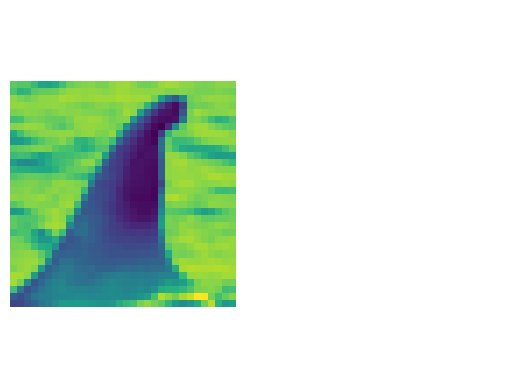

In [7]:
show_random_dataset_image(all_images)

<font color='magenta'>What is the difference between image size and torch image size? (2 pts)

*The image size describes the image's visual resolution. The torch image size describes the shape of the image tensor used by PyTorch. The PyTorch has the number of dimensions and the size of each dimension in memory. The first output represents a 2D tensor (a matrix) which is a grey image with a height of 32 pixels and a width of 32 pixels. The second output represents a 3D tensor which is a colored image (RGB) where it has 3 color channels (red, green, blue) and a height of 32 pixels and a width of 32 pixels.*

<font color='magenta'>Add a new transformation to the training data. After your first run of this model during class time, resize the image to 224x224 pixels. (2 pts)

Image size is {torch.Size([224, 224])}
torch.Size([3, 224, 224])


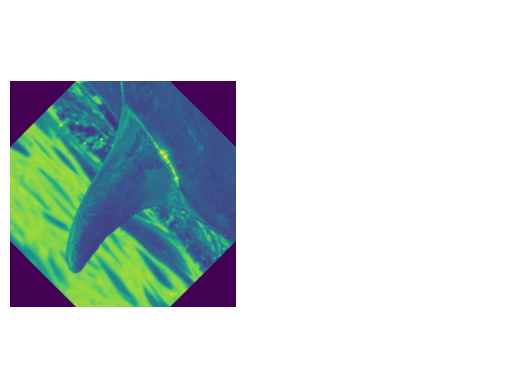

In [8]:
## ADD YOUR TRANSFORMATION HERE
transform = transforms.Compose([
            transforms.Resize([224,224]), # Resize the image as our model is optimized for 224x224 pixels
            transforms.ToTensor(),
            #adding a roation transformation
            transforms.RandomRotation(degrees=(90, 180)),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])]) # Normalize the data, these are the values that ResNet suggests based on their training data (natural scences))

all_images = datasets.ImageFolder(images, transform )
show_random_dataset_image(all_images)

<font color='magenta'>How did your transformation impact the images? (1 pt)

*I included a random rotation as a new transformation, and it turned the image randomly. I specified a rotation between 90 and 180 degrees.*

### Creating datasets used in training and testing

After loading in the data, we separate the data into training, validation, and testing datasets. The training data is inputted into the model during the training phase, and the model's predictions from this data is used to modulate the weights of the model. The validation data is used while the model trains, but the model is in a evaluation rather than training mode. The validation data gives us a real time view on how accurately the model is predicting our labels. The testing data is used after the model has completed training and tells us how successful our model will be with a novel dataset.

Once creating these 3 datasets, we prepare dataloaders which are used to load the images into our models. These images are loaded in batches into the model (a parameter called batch size). Because our dataset is imbalanced, we use a weighted random sampler to select images for our batches in the dataloader. Therefore to create our dataloader, we start by creating a function to get weights, calculating weights, initiating our weighted random sampler, and then creating our dataloaders.

<font color='green'>The below code eastablishes the data split between training, validation, and testing.

In [9]:
train_size = int(0.7 * len(all_images))
val_size = int(0.15 * len(all_images))
test_size = len(all_images) - (train_size + val_size)
print(train_size, val_size, test_size)
assert train_size + val_size + test_size == len(all_images)

1955 419 420


In [10]:
train_set, val_set, test_set = torch.utils.data.random_split(all_images, [train_size, val_size, test_size])

<font color='green'>The below function is used to get weights for the image classes.

In [14]:
def _get_weights(subset,full_dataset):
    ys = np.array([y for _, y in subset])
    counts = np.bincount(ys)
    label_weights = 1.0 / counts
    weights = label_weights[ys]

    print("Number of images per class:")
    for c, n, w in zip(full_dataset.classes, counts, label_weights):
        print(f"\t{c}:\tn={n}\tweight={w}")
        
    return weights

In [15]:
train_weights = _get_weights(train_set,all_images)
train_sampler = WeightedRandomSampler(train_weights, len(train_weights))

Number of images per class:
	beluga:	n=454	weight=0.0022026431718061676
	common_dolphin:	n=49	weight=0.02040816326530612
	false_killer_whale:	n=718	weight=0.001392757660167131
	fin_whale:	n=120	weight=0.008333333333333333
	gray_whale:	n=47	weight=0.02127659574468085
	humpback_whale:	n=567	weight=0.001763668430335097


<font color='magenta'>What is the impact of the class weight on how data is loaded into the model? What does it mean if a class has a low vs high weight? (2 pts)

<details>
  <summary>Hint</summary>
  
Check out this resource: https://towardsdatascience.com/demystifying-pytorchs-weightedrandomsampler-by-example-a68aceccb452 


*These weights represent the probability that an image will be selected. The probability is between 0 and 1. If a class has a low weight then the probability of it being chosen for the model is low. The opposite is true of a class with high weight: it will be chosen more often for the model.*

In [16]:
train_loader = DataLoader(train_set, batch_size=48, drop_last=True, sampler=train_sampler)
val_loader = DataLoader(val_set, batch_size=48, drop_last=True, shuffle=True)
test_loader = DataLoader(test_set, batch_size=48, drop_last=True, shuffle=True)

### Picking hyperparameters

We can set a few hyperparameters that we decide and can tune. These include:

- Learning rate = how much to update our model's parameters at each batch/epoch
- batch size = the number of data samples to pass through the network before updating it
    - If you change the batchsize below, make sure you ALSO change it in the commands above for the DataLoader
- Number of epochs = # of times to iterate over the dataset in model training

In [17]:
learning_rate=1e-3
batchsize=48
epochs=5

<font color='magenta'>How would model training be impacted if we decreased our learning rate? What about if we increased it? (2 pts)

*If we decreased our learning rate then it would be more percise but not learn as fast. If we increase our learning rate, then the model will train faster initalilly but would not be as percise.*

### Training our model

For part 1, we are going to use the model ResNet18. This is a published model for imaging data. Resnet18 is built from 4 residual blocks with two convolutional layers (Conv2d). Each convolutional layer is followed by a batch normalization step (BatchNorm2D) and a ReLU activation layer (ReLU). There is also a shortcut connection which adds input to output and allows the network to learn residual mapping.

I provided the complete code for the ResNet18 model. In the future, if you want to use resnet18, you can load it simply by running `resnet18_model = torchvision.models.resnet18(weights = False, progress  = True, num_classes=XXX)`. We will look at the full code for the model so you can see how this model was created.  

<font color='green'>The below code builds the residual blocks that ResNet18 uses in the model.

In [15]:
## First, we create the basic block that will be used in our residual net
class BasicBlock(nn.Module):
    # Initializing method for the basic block (It's OOP!)
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        ## Conv1: convolution layer, batch normalization, ReLU activation
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        ## Conv2: convolution layer, batch normalization
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        ## Shortcut connection: adds input to output
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    # The forward method calls on each layer
    def forward(self, x):
        ## Conv1: convolution layer, batch normalization, ReLU activation
        out = self.conv1(x) 
        out = self.bn1(out)
        out = self.relu(out)
        ## Conv2: convolution layer, batch normalization
        out = self.conv2(out)
        out = self.bn2(out)
        ## Shortcut connection
        out += self.shortcut(x)
        ## Final activation
        out = self.relu(out)
        return out

<font color='green'>The below code builds and initializes the ResNet18 model.

In [16]:
## Next, we put together these building blocks and create our residual net
class ResNet18(nn.Module):
    # specify the number of classes that we are predicting
    def __init__(self, num_classes=6):
        super(ResNet18, self).__init__()
        # In channels = Num pixels in H + Num pixels in W
        self.in_channels = 64
        
        # First convolution set (convolution, batch norm, relu)
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        # Our building blocks
        # The numbers correspond to the matrix shape
        ### We increase the number of filters/channels (i.e., the first number) as we go
        self.layer1 = self._make_layer(BasicBlock, 64, 2, stride=1)
        self.layer2 = self._make_layer(BasicBlock, 128, 2, stride=2)
        self.layer3 = self._make_layer(BasicBlock, 256, 2, stride=2)
        self.layer4 = self._make_layer(BasicBlock, 512, 2, stride=2)

        # Average pooling 
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # Final layer that makes the classification
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_channels, out_channels, stride))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        # First convolution set (convolution, batch norm, relu)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        # Our 4 building blocks
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        # Final layer that makes the classification
        out = self.fc(out)
        return out

## Getting our model and transferring it to the GPU
model = ResNet18().to(device)
print(model)

ResNet18(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=

<font color='green'>The below code eastablishes the loss function and optimizer used in training the model.

In [17]:
#define loss function & optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

<font color='green'>The below functions are used to train, evaluate, and test the Machine Learning model.

*Here is my API: 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*

In [18]:
wandb.init(
    project="BGMP_HappyWhale",
    name="Catie-HappyWhale-SpeciesDataset-hyperparameters", ### Update with your name!
    config={"learning rate":0.001,
        "architecture": "CNN",
        "dataset": "Species",
        "epochs":5}
)

num_epochs = epochs
train_losses, train_acc_list, val_losses, val_acc_list = [], [], [],[]

for epoch in range(num_epochs):
    # Setting model to "training mode"
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    batch=0

    # For each batch of data within the loader
    for inputs, labels in train_loader:
        # Send our input images and their labels to the GPU
        inputs, labels = inputs.to(device), labels.to(device)
        # Zero the gradients
        optimizer.zero_grad()
        # Inputting our training images into the model
        # and Predicting the image classification label
        outputs = model(inputs)
        # Figuring out the loss from our predictions
        loss = criterion(outputs, labels)
        # Compute gradients (aka backward pass)
        loss.backward()
        # Update model parameters
        optimizer.step()

        # Adding the loss to our running sum
        # Loss is calculated for each batch within an epoch
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        batch+=1
        print(f'Epoch [{epoch+1}/{num_epochs}] | Batch #{batch} | Batch Accuracy {(correct/total)*100:.2f}%')


    # Getting metrics for our training pass 
    train_loss = running_loss / len(train_loader.dataset)
    train_acc = 100. * correct / total
    train_losses.append(train_loss)
    train_acc_list.append(train_acc)
    
    # Switching our model to "evaluation mode"
    model.eval()
    running_loss = 0.0
    correct, total = 0, 0
    # Disable gradient calculation b/c we are evalulating the model
    with torch.no_grad():
        # Load in batches of our validation data
        for inputs, labels in val_loader:
            # Send test images and labels to the GPU
            inputs, labels = inputs.to(device), labels.to(device)
            # Predict the image classification label
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            # Figuring out how many predicted labels = true labels
            correct += predicted.eq(labels).sum().item()

            # Figuring out the loss from our predictions
            loss = criterion(outputs, labels)
            # Adding the loss to our running sum
            # Loss is calculated for each batch within an epoch
            running_loss += loss.item() * inputs.size(0)
    # Getting our accuracy from our test data
    val_acc = 100. * correct / total
    val_acc_list.append(val_acc)
    # Getting the loss from our test data
    val_loss = running_loss / len(val_loader.dataset)
    val_losses.append(val_loss)
    
    print(f'Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | Val Loss: {val_loss:.2f}%')

    # log metrics to wandb
    wandb.log({"validation_accuracy": val_acc, "validation_loss": val_loss, "train_loss":train_loss})

wandb.finish()

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/catcar/.netrc.
wandb: Currently logged in as: catcar (BGMP_HappyWhale) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch [1/5] | Batch #1 | Batch Accuracy 12.50%
Epoch [1/5] | Batch #2 | Batch Accuracy 18.75%
Epoch [1/5] | Batch #6 | Batch Accuracy 27.78%
Epoch [1/5] | Batch #11 | Batch Accuracy 38.26%
Epoch [1/5] | Batch #12 | Batch Accuracy 40.62%
Epoch [1/5] | Batch #13 | Batch Accuracy 40.71%
Epoch [1/5] | Batch #14 | Batch Accuracy 41.96%
Epoch [1/5] | Batch #15 | Batch Accuracy 43.61%
Epoch [1/5] | Batch #16 | Batch Accuracy 44.40%
Epoch [1/5] | Batch #17 | Batch Accuracy 44.85%
Epoch [1/5] | Batch #18 | Batch Accuracy 46.06%
Epoch [1/5] | Batch #19 | Batch Accuracy 46.27%
Epoch [1/5] | Batch #20 | Batch Accuracy 47.19%
Epoch [1/5] | Batch #21 | Batch Accuracy 48.41%
Epoch [1/5] | Batch #22 | Batch Accuracy 48.86%
Epoch [1/5] | Batch #23 | Batch Accuracy 49.28%
Epoch [1/5] | Batch #24 | Batch Accuracy 49.74%
Epoch [1/5] | Batch #25 | Batch Accuracy 49.75%
Epoch [1/5] | Batch #26 | Batch Accuracy 50.48%
Epoch [1/5] | Batch #27 | Batch Accuracy 50.85%
Epoch [1/5] | Batch #28 | Batch Accuracy 51

train_loss,█▄▃▃▁
validation_accuracy,▄▇█▅▁
validation_loss,▃▂▁▂█
train_loss,0.77519
validation_accuracy,39.0625
validation_loss,2.05795


#### For our class training, run the below model and consider the success of the model training. 

<font color='magenta'>What is your starting accuracy and final accuracy? What happened to the model to change the accuracy from epoch 1 to 5? (2 pts)

*The starting accuracy is 25.00%*

*The final accuracy is: 75.26%*

*The model changed accuracy from epoch 1 to 5 because during the training process the model updates the model's internal parameters (weights and biases) to minimize errors and improve the accuracy on the next training data/epoch.*

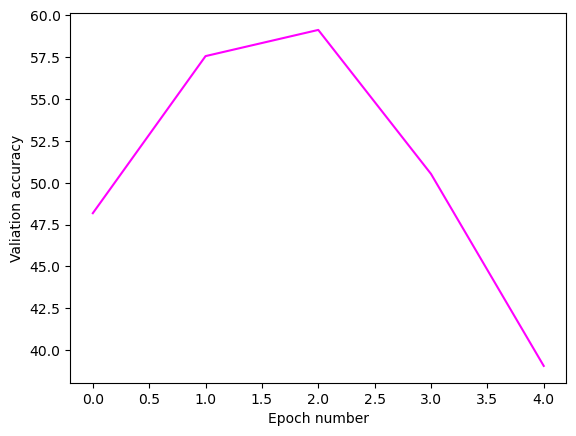

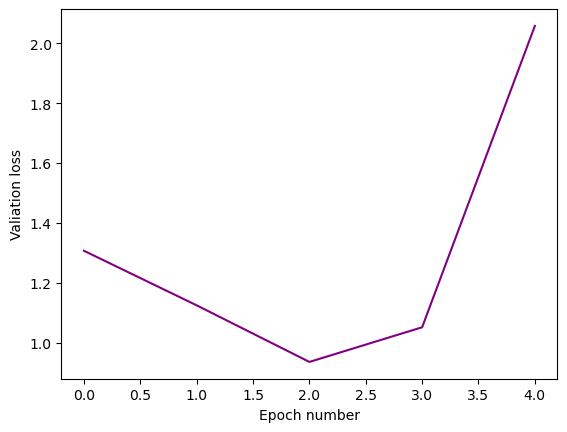

In [19]:
plt.plot(range(num_epochs), val_acc_list, color = "magenta")
plt.xlabel("Epoch number")
plt.ylabel("Valiation accuracy")
plt.show()  

plt.plot(range(num_epochs), val_losses, color = "purple")
plt.xlabel("Epoch number")
plt.ylabel("Valiation loss")
plt.show() 

<font color='green'>After running the model and calculating the overall accuracy, we can examine the data via a confusion matrix which highlights the accuracy by class.

[2 2 2 3 3 5 2 0 2 0 2 5 2 5 2 2 0 3 0 2 4 4 5 5 5 0 2 3 5 2 2 2 0 2 2 2 0
 2 2 5 2 0 0 3 5 2 2 0 5 2 2 0 0 5 2 4 0 2 3 2 2 0 3 2 0 2 2 2 2 0 0 0 2 0
 2 0 2 0 0 3 0 5 2 0 0 5 3 2 5 0 2 2 2 0 0 2 4 2 5 0 2 2 0 5 2 0 4 2 5 2 0
 0 2 0 5 5 2 0 5 2 2 5 5 2 5 2 3 2 2 2 3 4 2 5 0 5 5 5 5 5 3 2 2 2 5 5 5 5
 4 2 5 5 5 2 5 2 2 0 5 0 5 5 5 0 2 0 5 0 2 2 5 0 3 2 4 5 0 2 5 5 2 2 2 2 5
 5 0 5 2 2 5 0 5 3 2 2 2 2 2 2 5 2 5 2 0 0 4 2 5 5 5 2 5 0 2 2 0 2 5 5 5 5
 2 5 5 0 0 2 3 2 1 5 0 0 5 2 5 2 2 5 2 2 5 0 3 0 5 5 5 0 5 0 0 2 5 5 2 1 5
 5 5 4 0 5 0 0 5 2 1 2 0 2 5 2 0 2 3 0 5 5 2 5 0 0 0 2 0 3 5 2 2 2 1 0 4 5
 3 0 2 2 2 5 2 3 3 1 0 5 5 2 5 2 2 2 5 2 2 5 5 3 3 2 0 4 2 0 2 5 2 2 5 3 4
 5 3 2 2 0 5 5 2 3 5 3 0 4 5 1 0 3 4 2 0 0 2 2 5 5 2 5 2 5 2 2 0 2 2 5 5 2
 0 2 0 0 5 0 2 5 2 0 0 0 2 0 4 0 2 2 5 2 5 2 5 2 2 0 2 0 0 5 2 2 2 0 3 3 5
 5 5 0 5 0 5 2 5 0 5 0 5 5]


/tmp/ipykernel_2927720/2764316866.py:50: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  annot[i, j] = '%.1f%%\n%d/%d' % (p, c, s)


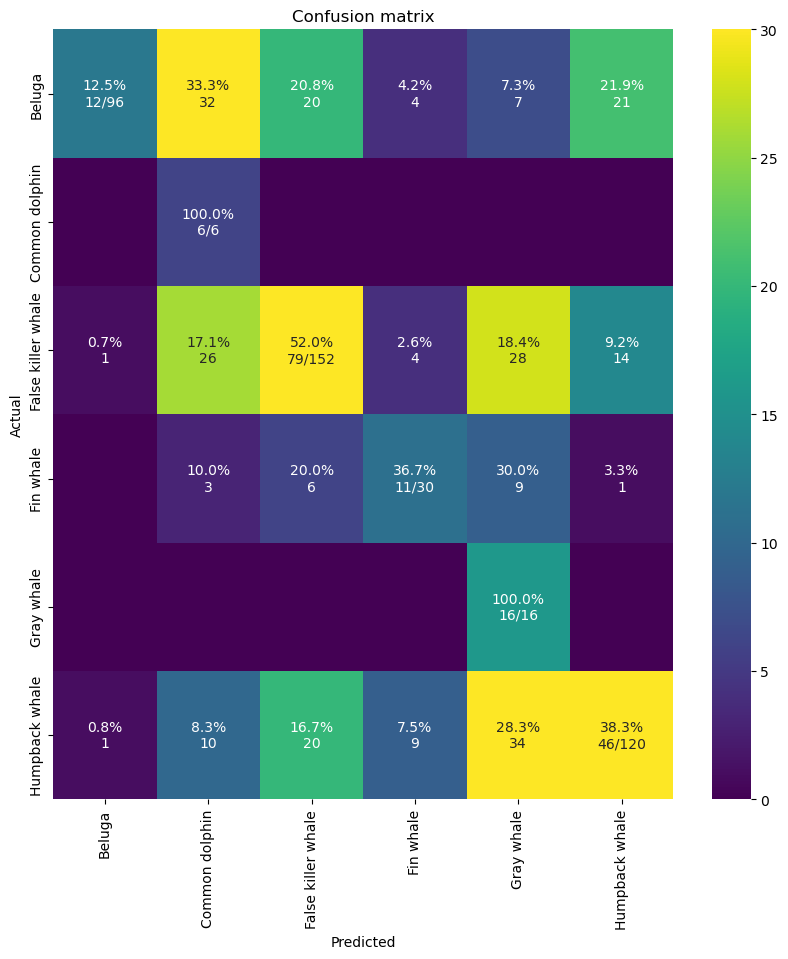

In [20]:
# predict the test dataset
def predict(model, dataset):
    dataset_prediction = []
    dataset_groundtruth = []
    model = model
    with torch.no_grad():
        for x, y_true in dataset:
            inp = x[None]
            y_pred = model(inp)
            dataset_prediction.append(y_pred.argmax().cpu().numpy())
            dataset_groundtruth.append(y_true)
    
    return np.array(dataset_prediction), np.array(dataset_groundtruth)
            
    # create seaborn heatmap with required labels
    ax=sns.heatmap(cm, annot=annot, fmt='', vmax=30, xticklabels=x_axis_labels, yticklabels=y_axis_labels)
    ax.set_title(title)

# Plot confusion matrix 
# orginally from Runqi Yang; 
# see https://gist.github.com/hitvoice/36cf44689065ca9b927431546381a3f7
def cm_analysis(y_true, y_pred, title, figsize=(10,10)):
    """
    Generate matrix plot of confusion matrix with pretty annotations.
    The plot image is saved to disk.
    args: 
      y_true:    true label of the data, with shape (nsamples,)
      y_pred:    prediction of the data, with shape (nsamples,)
      filename:  filename of figure file to save
      labels:    string array, name the order of class labels in the confusion matrix.
                 use `clf.classes_` if using scikit-learn models.
                 with shape (nclass,).
      ymap:      dict: any -> string, length == nclass.
                 if not None, map the labels & ys to more understandable strings.
                 Caution: original y_true, y_pred and labels must align.
      figsize:   the size of the figure plotted.
    """
    labels = ['Beluga','Common dolphin', 'False killer whale', 'Fin whale', 'Gray whale','Humpback whale']
    cm = confusion_matrix(y_true, y_pred)
    cm_sum = np.sum(cm, axis=1, keepdims=True)
    cm_perc = cm / cm_sum.astype(float) * 100
    annot = np.empty_like(cm).astype(str)
    nrows, ncols = cm.shape
    for i in range(nrows):
        for j in range(ncols):
            c = cm[i, j]
            p = cm_perc[i, j]
            if i == j:
                s = cm_sum[i]
                annot[i, j] = '%.1f%%\n%d/%d' % (p, c, s)
            elif c == 0:
                annot[i, j] = ''
            else:
                annot[i, j] = '%.1f%%\n%d' % (p, c)
    cm = pd.DataFrame(cm, index=labels, columns=labels)
    cm.index.name = 'Actual'
    cm.columns.name = 'Predicted'
    fig, ax = plt.subplots(figsize=figsize)
                              
    x_axis_labels = ['Beluga','Common dolphin', 'False killer whale', 'Fin whale', 'Gray whale','Humpback whale'] # labels for x-axis
    y_axis_labels = ['Beluga','Common dolphin', 'False killer whale', 'Fin whale', 'Gray whale','Humpback whale'] # labels for y-axis
    ax=sns.heatmap(cm, annot=annot, fmt='', vmax=30, xticklabels=x_axis_labels, yticklabels=y_axis_labels, cmap = "viridis")
    ax.set_title(title)

## This plot only contains the test set of data
## The test set of data has not been seen by the model yet
y_pred, y_true = predict(model, test_set)

print(y_true)
cm_analysis(y_true, y_pred, "Confusion matrix")

### What features did the model use to make decisions?

Based on the confusion matrices and validation loss, it is clear that the model is learning. To determine the features that are involved in decision making, there are a few possible approaches. One options is shown below, integrated gradients. 

#### Understanding feature importance using Integrated Gradients

<font color='green'>Integrated gradients is an attribution method. Attribution methods score the input data based on the prediction that the model makes using scores for each feature. The gradient is the signal that tells the network how much to increase or decrease a certain weight in the network during backpropogation. These gradients are overlaid onto the images to showcase the regions on the images that influence the weights.

Run the below code. 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.6369936].


Annotated whale species 2
Predicted whale species 2


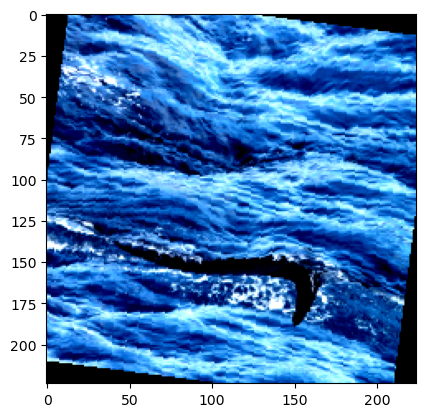

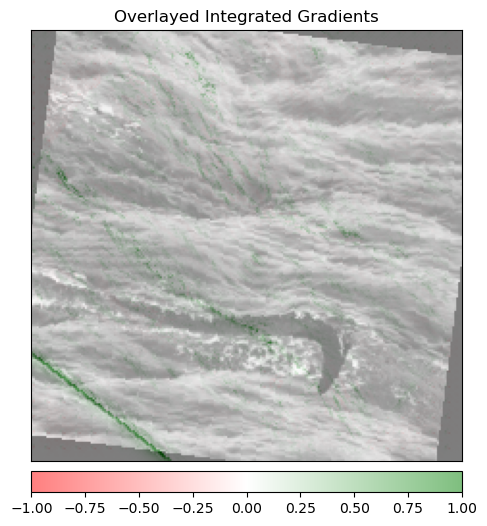

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.8112855].


Annotated whale species 2
Predicted whale species 5


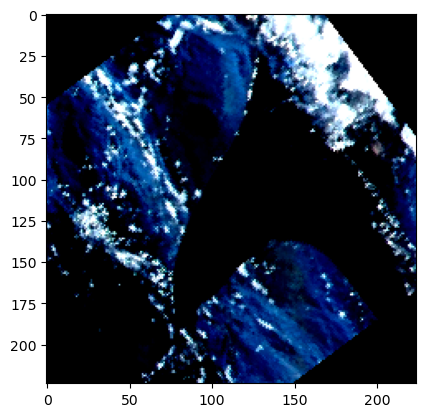

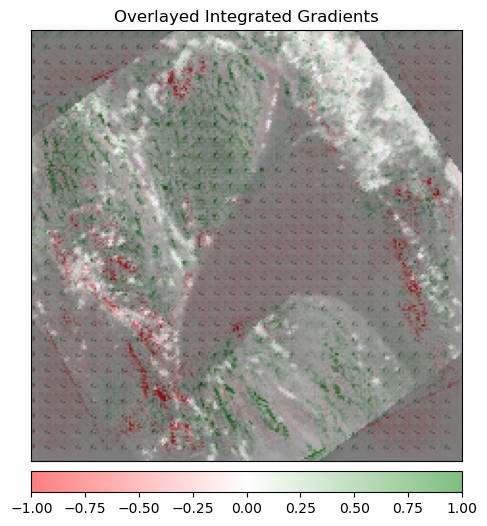

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.8025708].


Annotated whale species 4
Predicted whale species 4


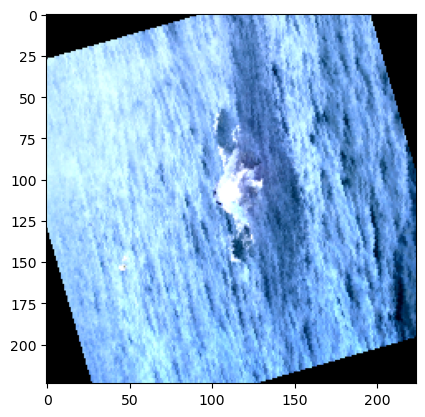

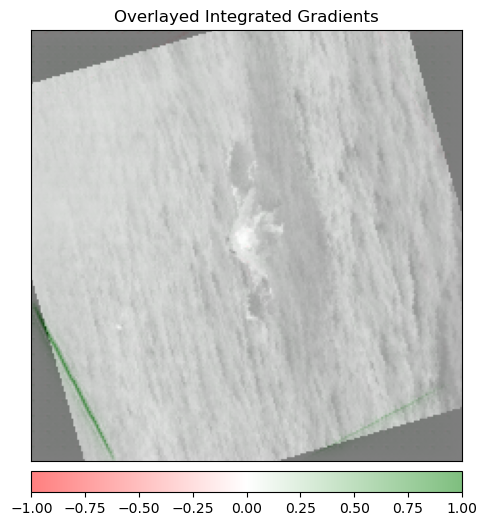

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.4278432].


Annotated whale species 0
Predicted whale species 2


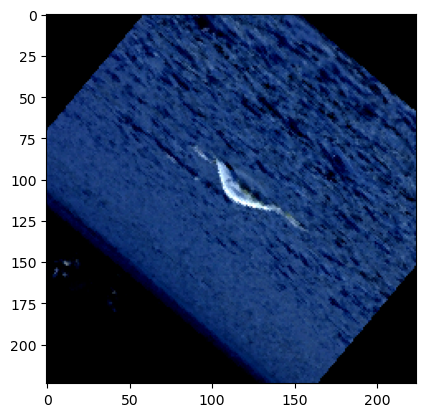

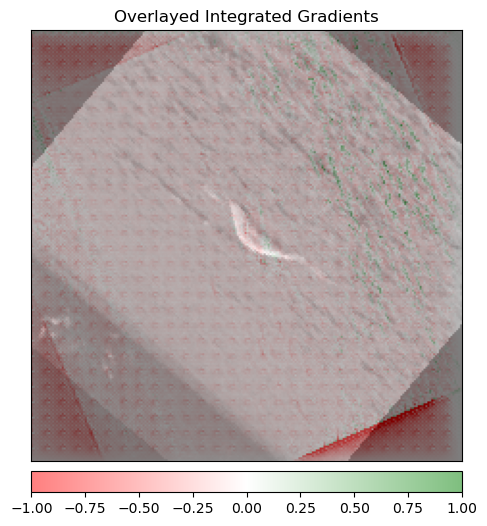

In [21]:
def visualize_ig(idx, 
                 _train_dataset=train_set, 
                 _test_dataset=test_set):
        
    # Get corresponding input and target tensors:
    input_tensor = _test_dataset[idx][0].unsqueeze(0)
    input_tensor.requires_grad = True
    target = _test_dataset[idx][1]
    
    # We will use the IntegratedGradients algorithm:
    algorithm = IntegratedGradients(model)
    
    # First we clear the gradients from the model:
    model.zero_grad()
    
    # Run attribution:
    attr_ig, delta = algorithm.attribute(input_tensor,
                                          target=target,
                                          baselines=input_tensor * 0,
                                          return_convergence_delta=True
                                        )
    
    # Integrated Gradients:
    attr_ig = np.transpose(attr_ig[0].cpu().detach().numpy(), (1, 2, 0))
    
    # Original image:
    original_image = np.transpose((_test_dataset[idx][0].detach().numpy() * 0.5) + 0.5, (1, 2, 0))
    
    print("Annotated whale species", test_true[idx])
    plt.imshow(original_image)
    
    
    print("Predicted whale species", test_pred[idx])


    # This visualises the attribution of labels to 
    viz.visualize_image_attr(attr_ig, 
                             original_image, 
                             method="blended_heat_map",
                             sign="all",
                             show_colorbar=True, 
                             title="Overlayed Integrated Gradients")

test_pred, test_true = predict(model, test_set)

visualize_ig(0)
visualize_ig(8)
visualize_ig(20)
visualize_ig(32)

<font color='magenta'>Does the integrated gradient show what types of features the model used to classify the images? Do you notice any potential problems? (2 pts)

*The intergrated gradient doesn't really show any type of distinct features to classify the images. I am noticing problems with the model getting rid of background noise and focusing on the features of importance.*

---

# Part 2 

Now that you have a sense for how to train a machine learning model, your task is to improve the success of our classification model.

**In three separate training events, make one (or more) modifications to the model training process, re-train the model, and report out your changes and whether they increased model accuracy. Why did you chose your particular change (curiousity, hypothesis, ect.)? Do you have ideas why your modifications were/were not successful?**

Types of changes that you can make include:
- [Using the pre-trained weights for ResNet18 (transfer learning)](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet18.html) 
- Changing hyperparameters (learning rate, batch size)
- [Changing transformation approach](https://docs.pytorch.org/vision/0.11/auto_examples/plot_transforms.html#sphx-glr-auto-examples-plot-transforms-py)
- [Changing the optimizer](https://docs.pytorch.org/docs/stable/optim.html)
- [Changing the model to a different pre-made model architecture](https://docs.pytorch.org/vision/main/models.html)
- Modifying the ResNet18 model
- Coming up with a whole new model!

If you decide to change any lines of code that are not in the below box, please add them to the box (DO NOT MODIFY ANY CODE ABOVE THIS MARKDOWN BOX - IT MAY BREAK PART 1). 

If your changes are ambitious, the code may take hours to run. If this is the case, please consider turning this notebook into a python script and running it via sBATCH. 

**Please note, you will NOT be graded by the success of your classifiers! It is okay if you are unable to improve the accuracy of the classifier**

#### Your Model 1 (10 pts)

<font color='magenta'>Describe your changes to the model training process (either changing something about the model, a hyperparameter, how data was inputted into the model, or another aspect) and why you selected those changes.

*I first choose to decrease the learning_rate. I am hoping that decreasing it from 1e-3 to 1e-5 will increase the precision.*

*I also choose to add a new transformation where it randomly changes the brightness, saturation, and other properties of the image. I am hoping that by changing the color of the image that the model won't heavly rely on colors in the background of the image such as the color of the sky, water, etc.*

In [19]:
#transformation
transform = transforms.Compose([
            transforms.Resize([224,224]), # Resize the image as our model is optimized for 224x224 pixels
            transforms.ToTensor(),
            #adding random color
            transforms.ColorJitter(brightness=.5, hue=.3),
            #adding a roation transformation
            transforms.RandomRotation(degrees=(90, 180)),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])]) # Normalize the data, these are the values that ResNet suggests based on their training data (natural scences))

all_images = datasets.ImageFolder(images, transform)

batchsize = 48
learning_rate=1e-5
epochs=5

train_loader = DataLoader(train_set, batch_size=batchsize, drop_last=True, sampler=train_sampler)
val_loader = DataLoader(val_set, batch_size=batchsize, drop_last=True, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batchsize, drop_last=True, shuffle=True)

In [20]:
## Model
#########
## First, we create the basic block that will be used in our residual net
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        ## Conv1: convolution layer, batch normalization, ReLU activation
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        ## Conv2: convolution layer, batch normalization
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        ## Shortcut connection: adds input to output
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    # The forward method calls on each layer
    def forward(self, x):
        ## Conv1: convolution layer, batch normalization, ReLU activation
        out = self.conv1(x) 
        out = self.bn1(out)
        out = self.relu(out)
        ## Conv2: convolution layer, batch normalization
        out = self.conv2(out)
        out = self.bn2(out)
        ## Shortcut connection
        out += self.shortcut(x)
        ## Final activation
        out = self.relu(out)
        return out

############
## Next, we put together these building blocks and create our residual net
class ResNet18(nn.Module):
    # specify the number of classes that we are predicting
    def __init__(self, num_classes=6):
        super(ResNet18, self).__init__()
        # In channels = Num pixels in H + Num pixels in W
        self.in_channels = 64
        
        # First convolution set (convolution, batch norm, relu)
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        # Our building blocks
        # The numbers correspond to the matrix shape
        ### We increase the number of filters/channels (i.e., the first number) as we go
        self.layer1 = self._make_layer(BasicBlock, 64, 2, stride=1)
        self.layer2 = self._make_layer(BasicBlock, 128, 2, stride=2)
        self.layer3 = self._make_layer(BasicBlock, 256, 2, stride=2)
        self.layer4 = self._make_layer(BasicBlock, 512, 2, stride=2)

        # Average pooling 
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # Final layer that makes the classification
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_channels, out_channels, stride))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        # First convolution set (convolution, batch norm, relu)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        # Our 4 building blocks
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        # Final layer that makes the classification
        out = self.fc(out)
        return out

## Getting our model and transferring it to the GPU
model = ResNet18().to(device)

#define loss function & optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [21]:
wandb.init(
    project="BGMP_HappyWhale",
    name="Catie-HappyWhale-SpeciesDataset-hyperparameters", ### Update with your name!
    config={"learning rate":0.001,
        "architecture": "CNN",
        "dataset": "Species",
        "epochs":5}
)

num_epochs = epochs
train_losses, train_acc_list, val_losses, val_acc_list = [], [], [],[]

for epoch in range(num_epochs):
    # Setting model to "training mode"
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    batch=0

    # For each batch of data within the loader
    for inputs, labels in train_loader:
        # Send our input images and their labels to the GPU
        inputs, labels = inputs.to(device), labels.to(device)
        # Zero the gradients
        optimizer.zero_grad()
        # Inputting our training images into the model
        # and Predicting the image classification label
        outputs = model(inputs)
        # Figuring out the loss from our predictions
        loss = criterion(outputs, labels)
        # Compute gradients (aka backward pass)
        loss.backward()
        # Update model parameters
        optimizer.step()

        # Adding the loss to our running sum
        # Loss is calculated for each batch within an epoch
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        batch+=1
        print(f'Epoch [{epoch+1}/{num_epochs}] | Batch #{batch} | Batch Accuracy {(correct/total)*100:.2f}%')


    # Getting metrics for our training pass 
    train_loss = running_loss / len(train_loader.dataset)
    train_acc = 100. * correct / total
    train_losses.append(train_loss)
    train_acc_list.append(train_acc)
    
    # Switching our model to "evaluation mode"
    model.eval()
    running_loss = 0.0
    correct, total = 0, 0
    # Disable gradient calculation b/c we are evalulating the model
    with torch.no_grad():
        # Load in batches of our validation data
        for inputs, labels in val_loader:
            # Send test images and labels to the GPU
            inputs, labels = inputs.to(device), labels.to(device)
            # Predict the image classification label
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            # Figuring out how many predicted labels = true labels
            correct += predicted.eq(labels).sum().item()

            # Figuring out the loss from our predictions
            loss = criterion(outputs, labels)
            # Adding the loss to our running sum
            # Loss is calculated for each batch within an epoch
            running_loss += loss.item() * inputs.size(0)
    # Getting our accuracy from our test data
    val_acc = 100. * correct / total
    val_acc_list.append(val_acc)
    # Getting the loss from our test data
    val_loss = running_loss / len(val_loader.dataset)
    val_losses.append(val_loss)
    
    print(f'Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | Val Loss: {val_loss:.2f}%')

    # log metrics to wandb
    wandb.log({"validation_accuracy": val_acc, "validation_loss": val_loss, "train_loss":train_loss})

wandb.finish()

Epoch [1/5] | Batch #1 | Batch Accuracy 18.75%
Epoch [1/5] | Batch #2 | Batch Accuracy 17.71%
Epoch [1/5] | Batch #3 | Batch Accuracy 20.14%
Epoch [1/5] | Batch #4 | Batch Accuracy 20.83%
Epoch [1/5] | Batch #5 | Batch Accuracy 22.08%
Epoch [1/5] | Batch #6 | Batch Accuracy 21.88%
Epoch [1/5] | Batch #7 | Batch Accuracy 21.73%
Epoch [1/5] | Batch #8 | Batch Accuracy 22.92%
Epoch [1/5] | Batch #9 | Batch Accuracy 23.84%
Epoch [1/5] | Batch #10 | Batch Accuracy 25.21%
Epoch [1/5] | Batch #11 | Batch Accuracy 26.33%
Epoch [1/5] | Batch #12 | Batch Accuracy 29.34%
Epoch [1/5] | Batch #13 | Batch Accuracy 29.97%
Epoch [1/5] | Batch #14 | Batch Accuracy 30.95%
Epoch [1/5] | Batch #15 | Batch Accuracy 32.08%
Epoch [1/5] | Batch #16 | Batch Accuracy 32.81%
Epoch [1/5] | Batch #17 | Batch Accuracy 34.19%
Epoch [1/5] | Batch #18 | Batch Accuracy 35.76%
Epoch [1/5] | Batch #19 | Batch Accuracy 36.73%
Epoch [1/5] | Batch #20 | Batch Accuracy 37.92%
Epoch [1/5] | Batch #21 | Batch Accuracy 38.59%
E

train_loss,█▄▃▂▁
validation_accuracy,▁▅▇▇█
validation_loss,█▄▂▂▁
train_loss,0.55408
validation_accuracy,69.79167
validation_loss,0.73551


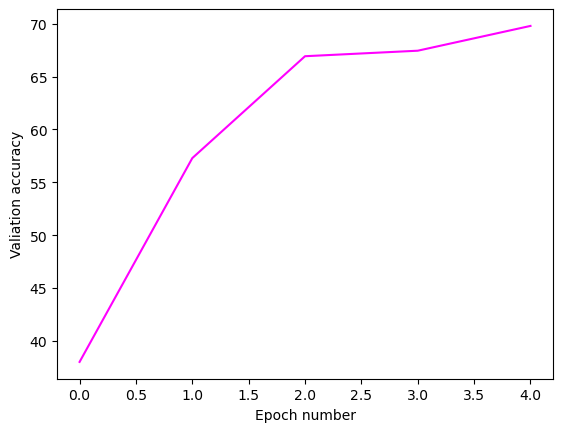

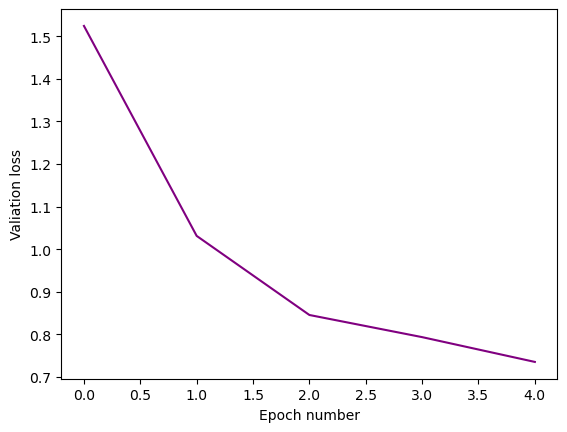

/tmp/ipykernel_900094/2764316866.py:50: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  annot[i, j] = '%.1f%%\n%d/%d' % (p, c, s)


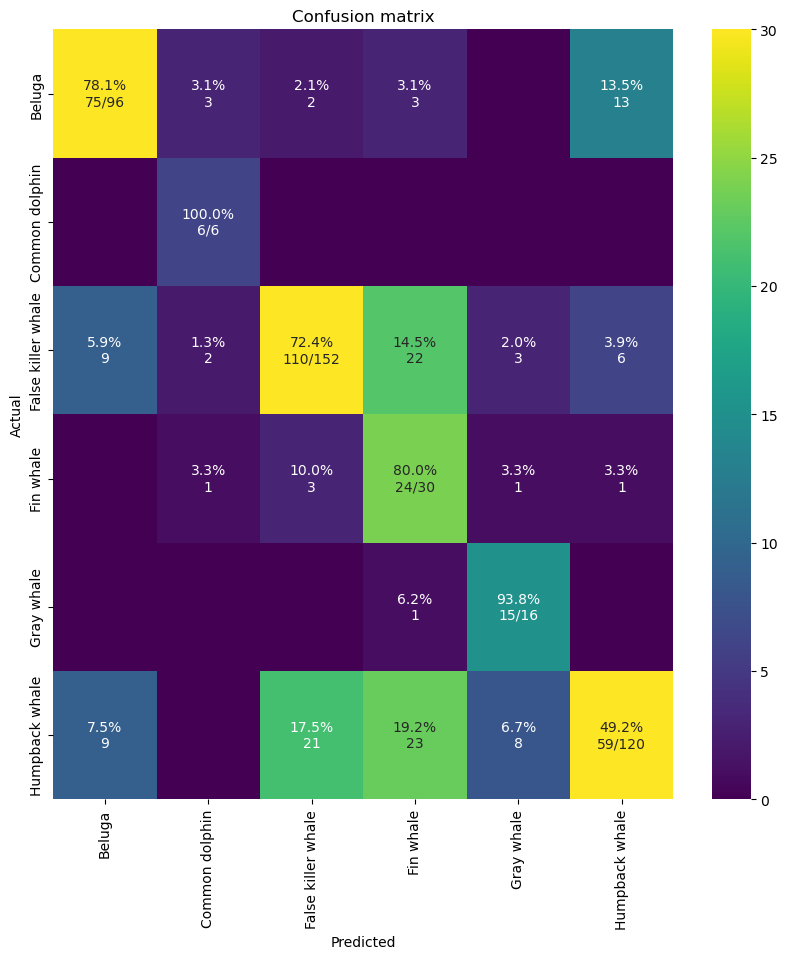

In [29]:
wandb.init(
    project="BGMP_HappyWhale",
    name="Catie-HappyWhale-SpeciesDataset-hyperparameters", ##update this with your name
    config={"learning rate":.01, # possibly update
        "architecture": "CNN",
        "dataset": "Species",
        "epochs": 5, "batch_size":48}  # possibly update
) 

plt.plot(range(epochs), val_acc_list, color = "magenta")
plt.xlabel("Epoch number")
plt.ylabel("Valiation accuracy")
plt.show()  

plt.plot(range(epochs), val_losses, color = "purple")
plt.xlabel("Epoch number")
plt.ylabel("Valiation loss")
plt.show()  

y_pred, y_true = predict(model, test_set)
cm_analysis(y_true, y_pred, "Confusion matrix")

[2 2 2 3 3 5 2 0 2 0 2 5 2 5 2 2 0 3 0 2 4 4 5 5 5 0 2 3 5 2 2 2 0 2 2 2 0
 2 2 5 2 0 0 3 5 2 2 0 5 2 2 0 0 5 2 4 0 2 3 2 2 0 3 2 0 2 2 2 2 0 0 0 2 0
 2 0 2 0 0 3 0 5 2 0 0 5 3 2 5 0 2 2 2 0 0 2 4 2 5 0 2 2 0 5 2 0 4 2 5 2 0
 0 2 0 5 5 2 0 5 2 2 5 5 2 5 2 3 2 2 2 3 4 2 5 0 5 5 5 5 5 3 2 2 2 5 5 5 5
 4 2 5 5 5 2 5 2 2 0 5 0 5 5 5 0 2 0 5 0 2 2 5 0 3 2 4 5 0 2 5 5 2 2 2 2 5
 5 0 5 2 2 5 0 5 3 2 2 2 2 2 2 5 2 5 2 0 0 4 2 5 5 5 2 5 0 2 2 0 2 5 5 5 5
 2 5 5 0 0 2 3 2 1 5 0 0 5 2 5 2 2 5 2 2 5 0 3 0 5 5 5 0 5 0 0 2 5 5 2 1 5
 5 5 4 0 5 0 0 5 2 1 2 0 2 5 2 0 2 3 0 5 5 2 5 0 0 0 2 0 3 5 2 2 2 1 0 4 5
 3 0 2 2 2 5 2 3 3 1 0 5 5 2 5 2 2 2 5 2 2 5 5 3 3 2 0 4 2 0 2 5 2 2 5 3 4
 5 3 2 2 0 5 5 2 3 5 3 0 4 5 1 0 3 4 2 0 0 2 2 5 5 2 5 2 5 2 2 0 2 2 5 5 2
 0 2 0 0 5 0 2 5 2 0 0 0 2 0 4 0 2 2 5 2 5 2 5 2 2 0 2 0 0 5 2 2 2 0 3 3 5
 5 5 0 5 0 5 2 5 0 5 0 5 5]


/tmp/ipykernel_900094/2764316866.py:50: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  annot[i, j] = '%.1f%%\n%d/%d' % (p, c, s)


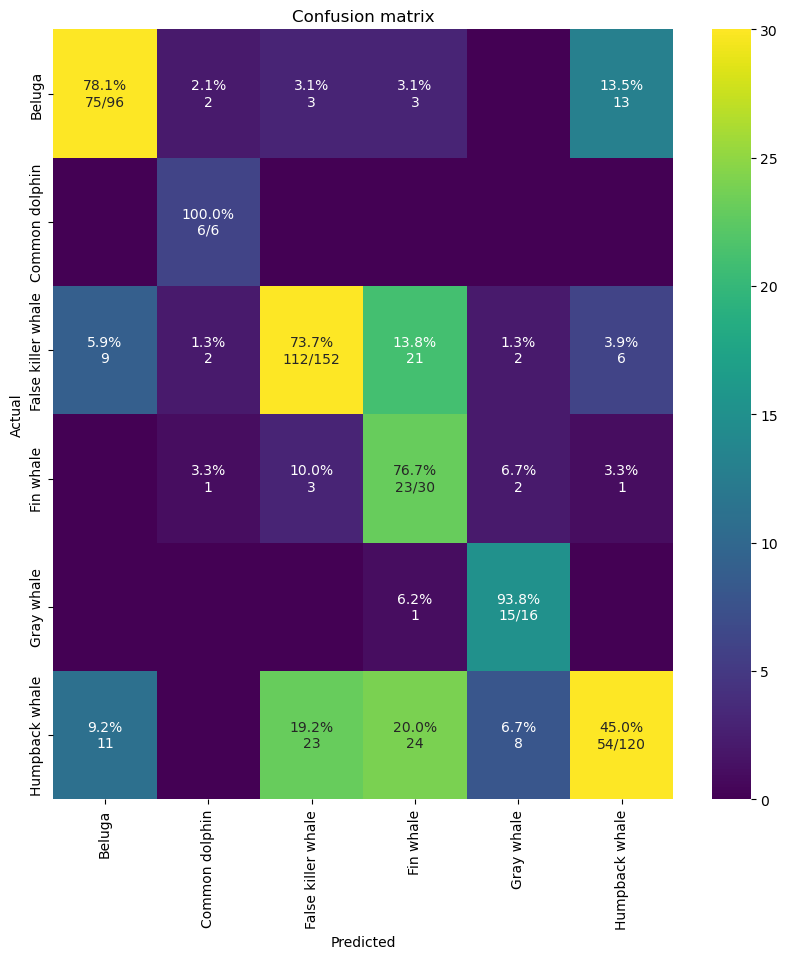

In [30]:
# predict the test dataset
def predict(model, dataset):
    dataset_prediction = []
    dataset_groundtruth = []
    model = model
    with torch.no_grad():
        for x, y_true in dataset:
            inp = x[None]
            y_pred = model(inp)
            dataset_prediction.append(y_pred.argmax().cpu().numpy())
            dataset_groundtruth.append(y_true)
    
    return np.array(dataset_prediction), np.array(dataset_groundtruth)
            
    # create seaborn heatmap with required labels
    ax=sns.heatmap(cm, annot=annot, fmt='', vmax=30, xticklabels=x_axis_labels, yticklabels=y_axis_labels)
    ax.set_title(title)

# Plot confusion matrix 
# orginally from Runqi Yang; 
# see https://gist.github.com/hitvoice/36cf44689065ca9b927431546381a3f7
def cm_analysis(y_true, y_pred, title, figsize=(10,10)):
    """
    Generate matrix plot of confusion matrix with pretty annotations.
    The plot image is saved to disk.
    args: 
      y_true:    true label of the data, with shape (nsamples,)
      y_pred:    prediction of the data, with shape (nsamples,)
      filename:  filename of figure file to save
      labels:    string array, name the order of class labels in the confusion matrix.
                 use `clf.classes_` if using scikit-learn models.
                 with shape (nclass,).
      ymap:      dict: any -> string, length == nclass.
                 if not None, map the labels & ys to more understandable strings.
                 Caution: original y_true, y_pred and labels must align.
      figsize:   the size of the figure plotted.
    """
    labels = ['Beluga','Common dolphin', 'False killer whale', 'Fin whale', 'Gray whale','Humpback whale']
    cm = confusion_matrix(y_true, y_pred)
    cm_sum = np.sum(cm, axis=1, keepdims=True)
    cm_perc = cm / cm_sum.astype(float) * 100
    annot = np.empty_like(cm).astype(str)
    nrows, ncols = cm.shape
    for i in range(nrows):
        for j in range(ncols):
            c = cm[i, j]
            p = cm_perc[i, j]
            if i == j:
                s = cm_sum[i]
                annot[i, j] = '%.1f%%\n%d/%d' % (p, c, s)
            elif c == 0:
                annot[i, j] = ''
            else:
                annot[i, j] = '%.1f%%\n%d' % (p, c)
    cm = pd.DataFrame(cm, index=labels, columns=labels)
    cm.index.name = 'Actual'
    cm.columns.name = 'Predicted'
    fig, ax = plt.subplots(figsize=figsize)
                              
    x_axis_labels = ['Beluga','Common dolphin', 'False killer whale', 'Fin whale', 'Gray whale','Humpback whale'] # labels for x-axis
    y_axis_labels = ['Beluga','Common dolphin', 'False killer whale', 'Fin whale', 'Gray whale','Humpback whale'] # labels for y-axis
    ax=sns.heatmap(cm, annot=annot, fmt='', vmax=30, xticklabels=x_axis_labels, yticklabels=y_axis_labels, cmap = "viridis")
    ax.set_title(title)

## This plot only contains the test set of data
## The test set of data has not been seen by the model yet
y_pred, y_true = predict(model, test_set)

print(y_true)
cm_analysis(y_true, y_pred, "Confusion matrix")

<font color='magenta'>Were your changes successful? Do you have ideas why your changes were successful or not? 

*It looks to have been successful. I think that by decreasing the learning rate by just a bit made it more accuraete without causing too many issues. I also think that changing the input of the images into the model to have random color changes also helped the model not depend on background to make it's decisions.*

#### Your Model 2 (10pts)

<font color='magenta'>Describe your changes to the model training process (either changing something about the model, a hyperparameter, how data was inputted into the model, or another aspect) and why you selected those changes.

*I decided to keep the changes I made in model 1 and change the optimizer from `optim.Adam` to `optim.SGD`. Using SGD seems like it will be more simple and memory-efficient compared to Adam. SGD is also often better at generalizing large-scale vision tasks like this one.*

In [25]:
#transformation
transform = transforms.Compose([
            transforms.Resize([224,224]), # Resize the image as our model is optimized for 224x224 pixels
            transforms.ToTensor(),
            #adding random color
            transforms.ColorJitter(brightness=.5, hue=.3),
            #adding a roation transformation
            transforms.RandomRotation(degrees=(90, 180)),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])]) # Normalize the data, these are the values that ResNet suggests based on their training data (natural scences))

all_images = datasets.ImageFolder(images, transform)

batchsize = 48
learning_rate = 1e-5
epochs = 5

train_loader = DataLoader(train_set, batch_size=batchsize, drop_last=True, sampler=train_sampler)
val_loader = DataLoader(val_set, batch_size=batchsize, drop_last=True, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batchsize, drop_last=True, shuffle=True)

In [26]:
## Model
#########
## First, we create the basic block that will be used in our residual net
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        ## Conv1: convolution layer, batch normalization, ReLU activation
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        ## Conv2: convolution layer, batch normalization
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        ## Shortcut connection: adds input to output
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    # The forward method calls on each layer
    def forward(self, x):
        ## Conv1: convolution layer, batch normalization, ReLU activation
        out = self.conv1(x) 
        out = self.bn1(out)
        out = self.relu(out)
        ## Conv2: convolution layer, batch normalization
        out = self.conv2(out)
        out = self.bn2(out)
        ## Shortcut connection
        out += self.shortcut(x)
        ## Final activation
        out = self.relu(out)
        return out

############
## Next, we put together these building blocks and create our residual net
class ResNet18(nn.Module):
    # specify the number of classes that we are predicting
    def __init__(self, num_classes=6):
        super(ResNet18, self).__init__()
        # In channels = Num pixels in H + Num pixels in W
        self.in_channels = 64
        
        # First convolution set (convolution, batch norm, relu)
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        # Our building blocks
        # The numbers correspond to the matrix shape
        ### We increase the number of channels (i.e., the first number) as we go
        self.layer1 = self._make_layer(BasicBlock, 64, 2, stride=1)
        self.layer2 = self._make_layer(BasicBlock, 128, 2, stride=2)
        self.layer3 = self._make_layer(BasicBlock, 256, 2, stride=2)
        self.layer4 = self._make_layer(BasicBlock, 512, 2, stride=2)

        # Average pooling 
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # Final layer that makes the classification
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_channels, out_channels, stride))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        # First convolution set (convolution, batch norm, relu)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        # Our 4 building blocks
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        # Final layer that makes the classification
        out = self.fc(out)
        return out

## Getting our model and transferring it to the GPU
model = ResNet18().to(device)

#define loss function & optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)

train_loss,█▅▃▁
validation_accuracy,▁▅▇█
validation_loss,█▄▃▁
train_loss,1.64418
validation_accuracy,35.67708
validation_loss,1.5042


Epoch [1/5] | Batch #1 | Batch Accuracy 25.00%
Epoch [1/5] | Batch #2 | Batch Accuracy 31.25%
Epoch [1/5] | Batch #3 | Batch Accuracy 38.89%
Epoch [1/5] | Batch #4 | Batch Accuracy 40.10%
Epoch [1/5] | Batch #5 | Batch Accuracy 40.00%
Epoch [1/5] | Batch #6 | Batch Accuracy 40.97%
Epoch [1/5] | Batch #7 | Batch Accuracy 39.88%
Epoch [1/5] | Batch #8 | Batch Accuracy 41.67%
Epoch [1/5] | Batch #9 | Batch Accuracy 42.13%
Epoch [1/5] | Batch #10 | Batch Accuracy 41.04%
Epoch [1/5] | Batch #11 | Batch Accuracy 40.91%
Epoch [1/5] | Batch #12 | Batch Accuracy 41.15%
Epoch [1/5] | Batch #13 | Batch Accuracy 41.99%
Epoch [1/5] | Batch #14 | Batch Accuracy 41.82%
Epoch [1/5] | Batch #15 | Batch Accuracy 42.92%
Epoch [1/5] | Batch #16 | Batch Accuracy 42.58%
Epoch [1/5] | Batch #17 | Batch Accuracy 42.89%
Epoch [1/5] | Batch #18 | Batch Accuracy 42.48%
Epoch [1/5] | Batch #19 | Batch Accuracy 43.20%
Epoch [1/5] | Batch #20 | Batch Accuracy 43.02%
Epoch [1/5] | Batch #21 | Batch Accuracy 43.35%
E

train_loss,█▆▅▂▁
validation_accuracy,▁▄▅▄█
validation_loss,█▆▄▃▁
train_loss,1.45894
validation_accuracy,53.38542
validation_loss,1.34178


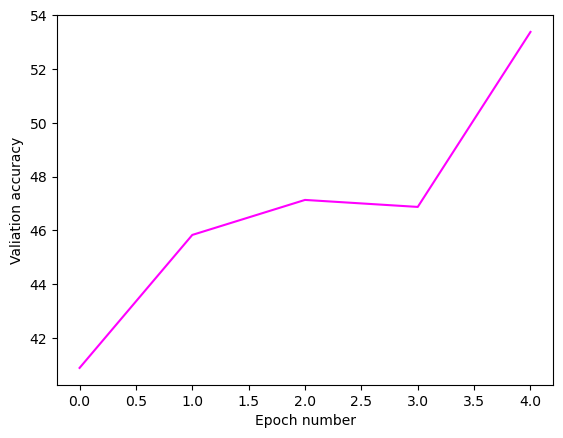

NameError: name 'validation_loss_list' is not defined

In [28]:
wandb.init(
    project="BGMP_HappyWhale",
    name="Catie-HappyWhale-SpeciesDataset-hyperparameters_mod2", ##update this with your name
    config={"learning rate":.001, # possibly update
        "architecture": "CNN",
        "dataset": "Species",
        "epochs": 5, "batch_size":48}  # possibly update
) 

batch=0
num_epochs = epochs
train_losses, train_acc_list, val_losses, val_acc_list = [], [], [],[]

for epoch in range(num_epochs):
    # Setting model to "training mode"
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    # For each batch of data within the loader
    for inputs, labels in train_loader:
        # Send our input images and their labels to the GPU
        inputs, labels = inputs.to(device), labels.to(device)
        # Zero the gradients
        optimizer.zero_grad()
        # Inputting our training images into the model
        # and Predicting the image classification label
        outputs = model(inputs)
        # Figuring out the loss from our predictions
        loss = criterion(outputs, labels)
        # Compute gradients (aka backward pass)
        loss.backward()
        # Update model parameters
        optimizer.step()

        # Adding the loss to our running sum
        # Loss is calculated for each batch within an epoch
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        batch+=1
        print(f'Epoch [{epoch+1}/{num_epochs}] | Batch #{batch} | Batch Accuracy {(correct/total)*100:.2f}%')


    # Getting metrics for our training pass 
    train_loss = running_loss / len(train_loader.dataset)
    train_acc = 100. * correct / total
    train_losses.append(train_loss)
    train_acc_list.append(train_acc)
    
    # Switching our model to "evaluation mode"
    model.eval()
    running_loss = 0.0
    correct, total = 0, 0
    # Disable gradient calculation b/c we are evalulating the model
    with torch.no_grad():
        # Load in batches of our validation data
        for inputs, labels in val_loader:
            # Send test images and labels to the GPU
            inputs, labels = inputs.to(device), labels.to(device)
            # Predict the image classification label
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            # Figuring out how many predicted labels = true labels
            correct += predicted.eq(labels).sum().item()

            # Figuring out the loss from our predictions
            loss = criterion(outputs, labels)
            # Adding the loss to our running sum
            # Loss is calculated for each batch within an epoch
            running_loss += loss.item() * inputs.size(0)
    # Getting our accuracy from our test data
    val_acc = 100. * correct / total
    val_acc_list.append(val_acc)
    # Getting the loss from our test data
    val_loss = running_loss / len(val_loader.dataset)
    val_losses.append(val_loss)
    
    print(f'Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | Val Loss: {val_loss:.2f}%')

    # log metrics to wandb
    wandb.log({"validation_accuracy": val_acc, "validation_loss": val_loss, "train_loss":train_loss})

wandb.finish()

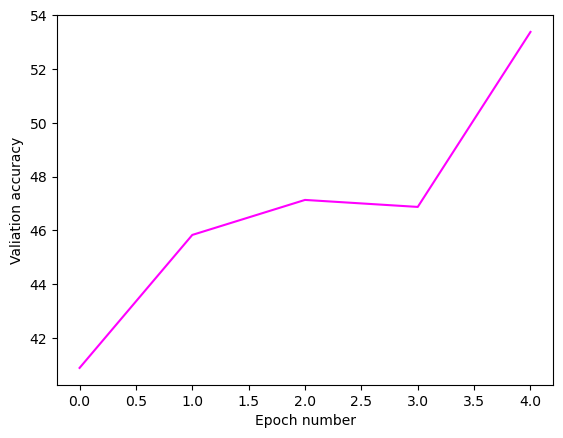

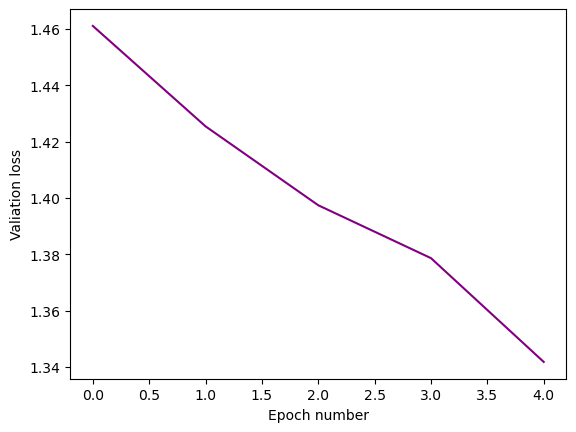

/tmp/ipykernel_2708878/2764316866.py:50: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  annot[i, j] = '%.1f%%\n%d/%d' % (p, c, s)


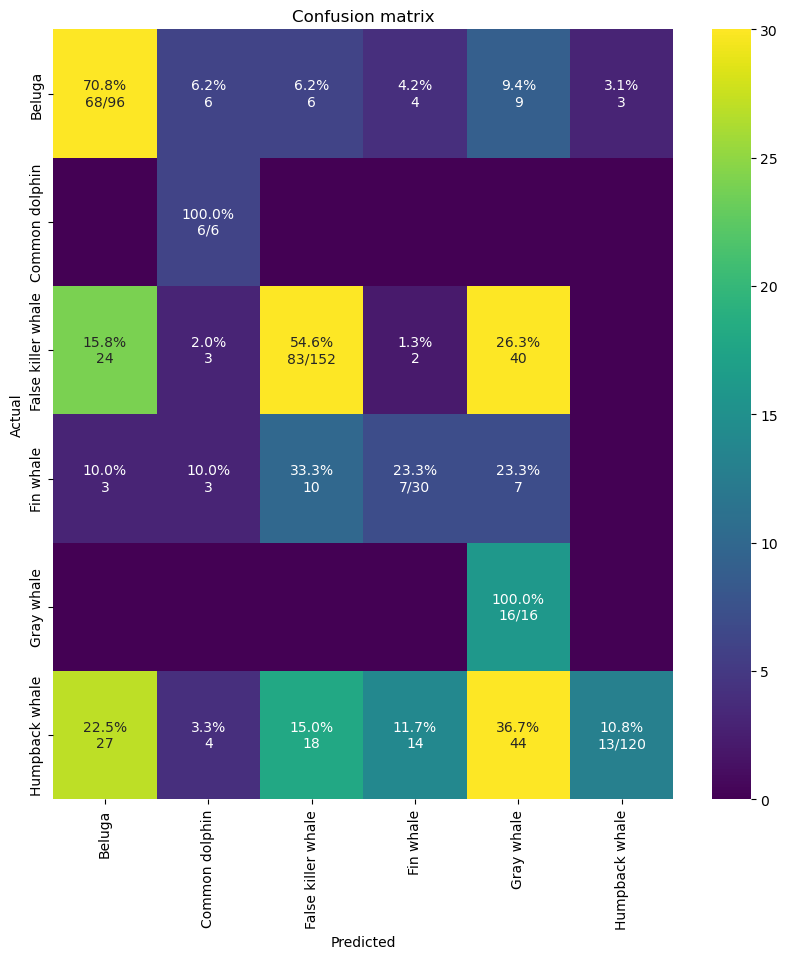

In [30]:
wandb.init(
    project="BGMP_HappyWhale",
    name="Catie-HappyWhale-SpeciesDataset-hyperparameters_mod2", ##update this with your name
    config={"learning rate":.01, # possibly update
        "architecture": "CNN",
        "dataset": "Species",
        "epochs": 5, "batch_size":48}  # possibly update
) 

plt.plot(range(epochs), val_acc_list, color = "magenta")
plt.xlabel("Epoch number")
plt.ylabel("Valiation accuracy")
plt.show()  

plt.plot(range(epochs), val_losses, color = "purple")
plt.xlabel("Epoch number")
plt.ylabel("Valiation loss")
plt.show()  

y_pred, y_true = predict(model, test_set)
cm_analysis(y_true, y_pred, "Confusion matrix")

<font color='magenta'>Were your changes successful? Do you have ideas why your changes were successful or not? 

*My changes were NOT successful. I think that SGD is not well suited for this data set.*

#### Your Model 3 (10 pts)

<font color='magenta'>Describe your changes to the model training process (either changing something about the model, a hyperparameter, how data was inputted into the model, or another aspect) and why you selected those changes.

*My first modification is to increase the batchsize from 42 to 80. Increasing the batch size I hope it will speed up the training but still keep the precision.*

*My second modification is to lower the epoch from 5 to 8. This will give the model more time to find patterns, and I'm hoping it makes the outcome better.*

In [33]:
batchsize = 80
learning_rate=1e-5
epochs = 8

train_loader = DataLoader(train_set, batch_size=batchsize, drop_last=True, sampler=train_sampler)
val_loader = DataLoader(val_set, batch_size=batchsize, drop_last=True, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batchsize, drop_last=True, shuffle=True)

In [34]:
## Model
#########
## First, we create the basic block that will be used in our residual net
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        ## Conv1: convolution layer, batch normalization, ReLU activation
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        ## Conv2: convolution layer, batch normalization
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        ## Shortcut connection: adds input to output
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    # The forward method calls on each layer
    def forward(self, x):
        ## Conv1: convolution layer, batch normalization, ReLU activation
        out = self.conv1(x) 
        out = self.bn1(out)
        out = self.relu(out)
        ## Conv2: convolution layer, batch normalization
        out = self.conv2(out)
        out = self.bn2(out)
        ## Shortcut connection
        out += self.shortcut(x)
        ## Final activation
        out = self.relu(out)
        return out

############
## Next, we put together these building blocks and create our residual net
class ResNet18(nn.Module):
    # specify the number of classes that we are predicting
    def __init__(self, num_classes=6):
        super(ResNet18, self).__init__()
        # In channels = Num pixels in H + Num pixels in W
        self.in_channels = 64
        
        # First convolution set (convolution, batch norm, relu)
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        # Our building blocks
        # The numbers correspond to the matrix shape
        ### We increase the number of channels (i.e., the first number) as we go
        self.layer1 = self._make_layer(BasicBlock, 64, 2, stride=1)
        self.layer2 = self._make_layer(BasicBlock, 128, 2, stride=2)
        self.layer3 = self._make_layer(BasicBlock, 256, 2, stride=2)
        self.layer4 = self._make_layer(BasicBlock, 512, 2, stride=2)

        # Average pooling 
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # Final layer that makes the classification
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_channels, out_channels, stride))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        # First convolution set (convolution, batch norm, relu)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        # Our 4 building blocks
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        # Final layer that makes the classification
        out = self.fc(out)
        return out

## Getting our model and transferring it to the GPU
model = ResNet18().to(device)

#define loss function & optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [35]:
wandb.init(
    project="BGMP_HappyWhale",
    name="Catie-HappyWhale-SpeciesDataset-hyperparameters_mod3", ##update this with your name
    config={"learning rate":.001, # possibly update
        "architecture": "CNN",
        "dataset": "Species",
        "epochs": 5, "batch_size":48}  # possibly update
) 

batch=0
num_epochs = epochs
train_losses, train_acc_list, val_losses, val_acc_list = [], [], [],[]

for epoch in range(num_epochs):
    # Setting model to "training mode"
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    # For each batch of data within the loader
    for inputs, labels in train_loader:
        # Send our input images and their labels to the GPU
        inputs, labels = inputs.to(device), labels.to(device)
        # Zero the gradients
        optimizer.zero_grad()
        # Inputting our training images into the model
        # and Predicting the image classification label
        outputs = model(inputs)
        # Figuring out the loss from our predictions
        loss = criterion(outputs, labels)
        # Compute gradients (aka backward pass)
        loss.backward()
        # Update model parameters
        optimizer.step()

        # Adding the loss to our running sum
        # Loss is calculated for each batch within an epoch
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        batch+=1
        print(f'Epoch [{epoch+1}/{num_epochs}] | Batch #{batch} | Batch Accuracy {(correct/total)*100:.2f}%')


    # Getting metrics for our training pass 
    train_loss = running_loss / len(train_loader.dataset)
    train_acc = 100. * correct / total
    train_losses.append(train_loss)
    train_acc_list.append(train_acc)
    
    # Switching our model to "evaluation mode"
    model.eval()
    running_loss = 0.0
    correct, total = 0, 0
    # Disable gradient calculation b/c we are evalulating the model
    with torch.no_grad():
        # Load in batches of our validation data
        for inputs, labels in val_loader:
            # Send test images and labels to the GPU
            inputs, labels = inputs.to(device), labels.to(device)
            # Predict the image classification label
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            # Figuring out how many predicted labels = true labels
            correct += predicted.eq(labels).sum().item()

            # Figuring out the loss from our predictions
            loss = criterion(outputs, labels)
            # Adding the loss to our running sum
            # Loss is calculated for each batch within an epoch
            running_loss += loss.item() * inputs.size(0)
    # Getting our accuracy from our test data
    val_acc = 100. * correct / total
    val_acc_list.append(val_acc)
    # Getting the loss from our test data
    val_loss = running_loss / len(val_loader.dataset)
    val_losses.append(val_loss)
    
    print(f'Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | Val Loss: {val_loss:.2f}%')

    # log metrics to wandb
    wandb.log({"validation_accuracy": val_acc, "validation_loss": val_loss, "train_loss":train_loss})

wandb.finish()

Epoch [1/8] | Batch #1 | Batch Accuracy 15.00%
Epoch [1/8] | Batch #2 | Batch Accuracy 19.38%
Epoch [1/8] | Batch #3 | Batch Accuracy 21.25%
Epoch [1/8] | Batch #4 | Batch Accuracy 24.06%
Epoch [1/8] | Batch #5 | Batch Accuracy 26.00%
Epoch [1/8] | Batch #6 | Batch Accuracy 27.71%
Epoch [1/8] | Batch #7 | Batch Accuracy 29.29%
Epoch [1/8] | Batch #8 | Batch Accuracy 31.87%
Epoch [1/8] | Batch #9 | Batch Accuracy 33.19%
Epoch [1/8] | Batch #10 | Batch Accuracy 35.25%
Epoch [1/8] | Batch #11 | Batch Accuracy 36.82%
Epoch [1/8] | Batch #12 | Batch Accuracy 37.40%
Epoch [1/8] | Batch #13 | Batch Accuracy 39.33%
Epoch [1/8] | Batch #14 | Batch Accuracy 40.62%
Epoch [1/8] | Batch #15 | Batch Accuracy 41.42%
Epoch [1/8] | Batch #16 | Batch Accuracy 42.58%
Epoch [1/8] | Batch #17 | Batch Accuracy 43.09%
Epoch [1/8] | Batch #18 | Batch Accuracy 44.10%
Epoch [1/8] | Batch #19 | Batch Accuracy 44.67%
Epoch [1/8] | Batch #20 | Batch Accuracy 45.81%
Epoch [1/8] | Batch #21 | Batch Accuracy 47.38%
E

train_loss,█▄▃▂▂▁▁▁
validation_accuracy,▁▄▆▇▇▇▇█
validation_loss,█▄▃▂▂▂▂▁
train_loss,0.50867
validation_accuracy,74.75
validation_loss,0.66259


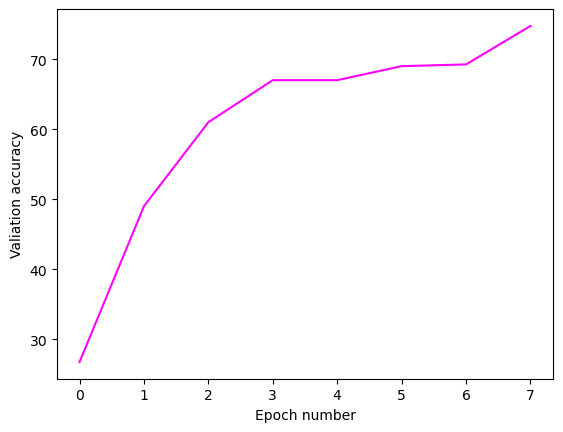

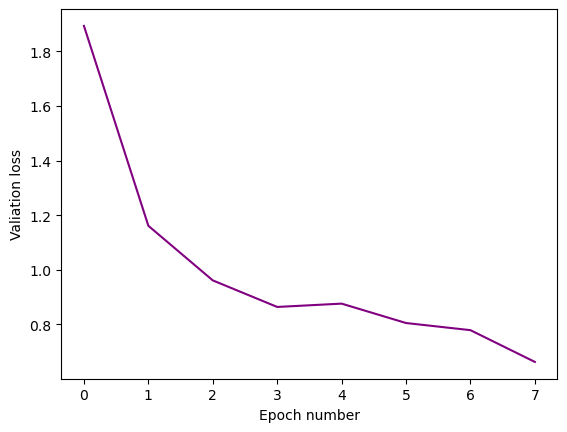

/tmp/ipykernel_2708878/2764316866.py:50: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  annot[i, j] = '%.1f%%\n%d/%d' % (p, c, s)


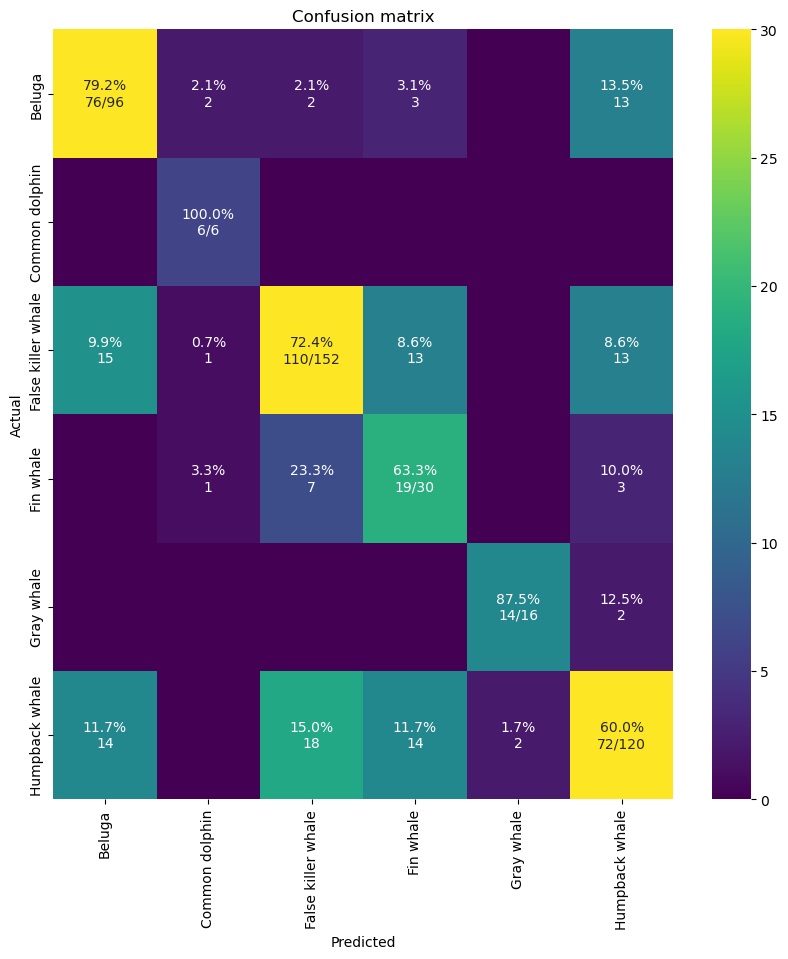

In [36]:
plt.plot(range(epochs), val_acc_list, color = "magenta")
plt.xlabel("Epoch number")
plt.ylabel("Valiation accuracy")
plt.show()  

plt.plot(range(epochs), val_losses, color = "purple")
plt.xlabel("Epoch number")
plt.ylabel("Valiation loss")
plt.show()  

y_pred, y_true = predict(model, test_set)
cm_analysis(y_true, y_pred, "Confusion matrix")

<font color='magenta'>Were your changes successful? Do you have ideas why your changes were successful or not? 

*Looks pretty successful with a end validation accuracy of 74.75%. I think that having more epochs allowed the model to train more and gave more time to tune. Increasing the batch size also might have played a role in increasing this accuracy.*

<font color='magenta'>Summarize your 3 steps, their success, and what you learned (5 pts)

*Modification 1: lowering the learning rate and adding a new transformation. It was very sucessful :) I learned that some combo of adding a new transformation and lowering the learning rate is good for this model but not ad good as the default given in part 1.*

*Modification 2: changed the optimizer from `Adam` to `SGD`. It was not sucessful :(. Maybe other paramaters need to be adjusted alongside the optimizer to make it better, but changing just the optimizer is not the move.*

*Modification 3: increasing the batchsize from 42 to 80 and lowering the epoch from 5 to 8. This was sucessful :). Overall giving the model more time probably increased it's accuracy in the most reliable way.*

# Part 3

After discussing with a group and looking at the top preforming models, the following changes were made:

- Decreasing learning rate from 1e-3 to 5e-3
- Increasing epochs from 5 to 11
- Changing optimizer from `optim.Adam` to `optim.SGD`
- Using the pre-trained weights from the ResNet18 model

In [18]:
batchsize = 32
learning_rate = 5e-3
epochs = 11

train_loader = DataLoader(train_set, batch_size=batchsize, drop_last=True, sampler=train_sampler)
val_loader = DataLoader(val_set, batch_size=batchsize, drop_last=True, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batchsize, drop_last=True, shuffle=True)

In [19]:
## Model: Changing the model to a different pre-made model architecture, with pre-trained weights
#########
import torchvision.models as models
from torchvision.models import resnet18, ResNet18_Weights

num_classes = 6 # same as mod1 and mod2
weights = ResNet18_Weights.DEFAULT

# Pre-trained torchvision ResNet18, ResNet18_Weights.DEFAULT (aka ResNet18_Weights.IMAGENET1K_V1)
model = resnet18(weights=weights)

# Replace classification head
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)

## Getting our model and transferring it to the GPU
model = model.to(device)

# Make sure transforms match the pre-trained weights, ResNet18_Weights.DEFAULT (aka ResNet18_Weights.IMAGENET1K_V1)
preprocess = weights.transforms()
train_set.transform = preprocess
val_set.transform = preprocess
test_set.transform = preprocess

#define loss function & optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=1e-4)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/catcar/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 376MB/s]


In [20]:
wandb.init(
    project="BGMP_HappyWhale",
    name="Catie-HappyWhale-SpeciesDataset-Part3_group_mods", ##update this with your name
    config={"learning rate":learning_rate, 
        "architecture": "CNN",
        "dataset": "Species",
        "epochs": epochs, "batch_size": batchsize}  
) 

batch=0
num_epochs = epochs
train_losses, train_acc_list, val_losses, val_acc_list = [], [], [],[]

for epoch in range(num_epochs):
    # Setting model to "training mode"
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    # For each batch of data within the loader
    for inputs, labels in train_loader:
        # Send our input images and their labels to the GPU
        inputs, labels = inputs.to(device), labels.to(device)
        # Zero the gradients
        optimizer.zero_grad()
        # Inputting our training images into the model
        # and Predicting the image classification label
        outputs = model(inputs)
        # Figuring out the loss from our predictions
        loss = criterion(outputs, labels)
        # Compute gradients (aka backward pass)
        loss.backward()
        # Update model parameters
        optimizer.step()

        # Adding the loss to our running sum
        # Loss is calculated for each batch within an epoch
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        batch+=1
        print(f'Epoch [{epoch+1}/{num_epochs}] | Batch #{batch} | Batch Accuracy {(correct/total)*100:.2f}%')


    # Getting metrics for our training pass 
    train_loss = running_loss / len(train_loader.dataset)
    train_acc = 100. * correct / total
    train_losses.append(train_loss)
    train_acc_list.append(train_acc)
    
    # Switching our model to "evaluation mode"
    model.eval()
    running_loss = 0.0
    correct, total = 0, 0
    # Disable gradient calculation b/c we are evalulating the model
    with torch.no_grad():
        # Load in batches of our validation data
        for inputs, labels in val_loader:
            # Send test images and labels to the GPU
            inputs, labels = inputs.to(device), labels.to(device)
            # Predict the image classification label
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            # Figuring out how many predicted labels = true labels
            correct += predicted.eq(labels).sum().item()

            # Figuring out the loss from our predictions
            loss = criterion(outputs, labels)
            # Adding the loss to our running sum
            # Loss is calculated for each batch within an epoch
            running_loss += loss.item() * inputs.size(0)
    # Getting our accuracy from our test data
    val_acc = 100. * correct / total
    val_acc_list.append(val_acc)
    # Getting the loss from our test data
    val_loss = running_loss / len(val_loader.dataset)
    val_losses.append(val_loss)
    
    print(f'Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | Val Loss: {val_loss:.2f}%')

    # log metrics to wandb
    wandb.log({"validation_accuracy": val_acc, "validation_loss": val_loss, "train_loss":train_loss})

wandb.finish()

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/catcar/.netrc.
wandb: Currently logged in as: catcar (BGMP_HappyWhale) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch [1/11] | Batch #1 | Batch Accuracy 21.88%
Epoch [1/11] | Batch #2 | Batch Accuracy 20.31%
Epoch [1/11] | Batch #3 | Batch Accuracy 18.75%
Epoch [1/11] | Batch #4 | Batch Accuracy 17.97%
Epoch [1/11] | Batch #5 | Batch Accuracy 19.38%
Epoch [1/11] | Batch #6 | Batch Accuracy 22.40%
Epoch [1/11] | Batch #7 | Batch Accuracy 22.32%
Epoch [1/11] | Batch #8 | Batch Accuracy 26.95%
Epoch [1/11] | Batch #9 | Batch Accuracy 27.43%
Epoch [1/11] | Batch #10 | Batch Accuracy 30.00%
Epoch [1/11] | Batch #11 | Batch Accuracy 33.81%
Epoch [1/11] | Batch #12 | Batch Accuracy 37.24%
Epoch [1/11] | Batch #13 | Batch Accuracy 40.38%
Epoch [1/11] | Batch #14 | Batch Accuracy 42.19%
Epoch [1/11] | Batch #15 | Batch Accuracy 42.92%
Epoch [1/11] | Batch #16 | Batch Accuracy 45.12%
Epoch [1/11] | Batch #17 | Batch Accuracy 47.24%
Epoch [1/11] | Batch #18 | Batch Accuracy 48.09%
Epoch [1/11] | Batch #19 | Batch Accuracy 49.84%
Epoch [1/11] | Batch #20 | Batch Accuracy 51.09%
Epoch [1/11] | Batch #21 | Ba

train_loss,█▃▂▂▁▁▁▁▁▁▁
validation_accuracy,▁▅▅▆▇▆▆▇█▆▇
validation_loss,█▄▆▄▂▃▄▃▁▅▃
train_loss,0.05061
validation_accuracy,96.63462
validation_loss,0.12554


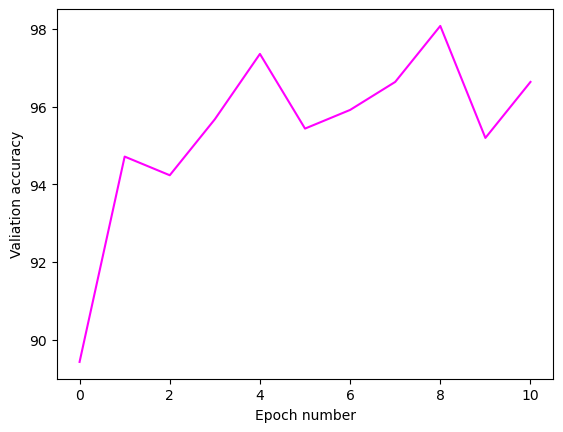

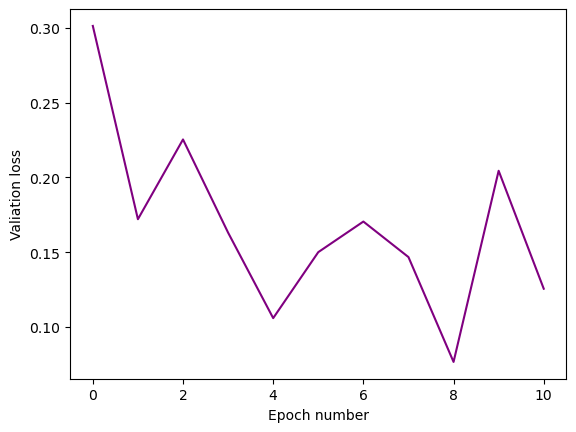

In [23]:
plt.plot(range(epochs), val_acc_list, color = "magenta")
plt.xlabel("Epoch number")
plt.ylabel("Valiation accuracy")
plt.show()  

plt.plot(range(epochs), val_losses, color = "purple")
plt.xlabel("Epoch number")
plt.ylabel("Valiation loss")
plt.show()  